# Laboratorio 8 - Deep Learning

Implementación de un Mini-GPT a nivel de carácter, comparación de estrategias de muestreo y análisis de embeddings contextuales con BERT multilingüe.

## Task 1.1 - Dataset, vocabulario y batches

El texto se codifica a nivel de carácter. Para cada secuencia de entrada $x_1,\ldots,x_T$, el objetivo es la misma secuencia desplazada un paso: $x_2,\ldots,x_{T+1}$.

In [1]:
import math
import os
import random
import time
import urllib.request
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 1337
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# Hiperparámetros mínimos solicitados
block_size = 128
d_model = 128
n_heads = 4
n_layers = 3
batch_size = 64
lr = 3e-4
epochs = 10

# Cada época representa 500 actualizaciones con batches aleatorios.
steps_per_epoch = 500
dropout = 0.1
grad_clip = 1.0

device: cuda


In [2]:
URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
data_path = Path("input.txt")

if not data_path.exists():
    urllib.request.urlretrieve(URL, data_path)

text = data_path.read_text(encoding="utf-8")
print("caracteres totales:", len(text))
print(text[:200])

caracteres totales: 1115394
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


In [3]:
chars = sorted(set(text))
vocab_size = len(chars)
assert vocab_size == 65, f"Se esperaban 65 caracteres y hay {vocab_size}"

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}

def encode(s):
    return [stoi[c] for c in s]

def decode(ids):
    return "".join(itos[int(i)] for i in ids)

assert decode(encode("ROMEO:")) == "ROMEO:"
print("vocab_size:", vocab_size)
readable_chars = {"\n": "salto de línea", " ": "espacio"}
print("vocabulario:")
print(" | ".join(readable_chars.get(ch, ch) for ch in chars))

vocab_size: 65
vocabulario:
salto de línea | espacio | ! | $ | & | ' | , | - | . | 3 | : | ; | ? | A | B | C | D | E | F | G | H | I | J | K | L | M | N | O | P | Q | R | S | T | U | V | W | X | Y | Z | a | b | c | d | e | f | g | h | i | j | k | l | m | n | o | p | q | r | s | t | u | v | w | x | y | z


In [4]:
data = torch.tensor(encode(text), dtype=torch.long)

# División temporal: no se mezcla información futura con entrenamiento.
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]
print("train:", len(train_data), "val:", len(val_data))

def get_batch(split):
    source = train_data if split == "train" else val_data
    starts = torch.randint(len(source) - block_size, (batch_size,))
    x = torch.stack([source[i : i + block_size] for i in starts])
    y = torch.stack([source[i + 1 : i + block_size + 1] for i in starts])
    return x.to(device), y.to(device)

xb, yb = get_batch("train")
print(xb.shape, yb.shape)
print(repr(decode(xb[0, :20])))
print(repr(decode(yb[0, :20])))

train: 1003854 val: 111540


torch.Size([64, 128]) torch.Size([64, 128])
' guess who caused yo'
'guess who caused you'


## Task 1.2 - Mini-GPT, entrenamiento y perplejidad

La máscara causal impone que la posición $t$ solo pueda atender posiciones $\leq t$. La pérdida es cross-entropy sobre los 65 caracteres del vocabulario.

In [5]:
class CausalSelfAttention(nn.Module):
    def __init__(self):
        super().__init__()
        assert d_model % n_heads == 0
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.proj = nn.Linear(d_model, d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        batch, length, channels = x.shape
        q, k, v = self.qkv(x).split(d_model, dim=2)
        head_dim = channels // n_heads
        q, k, v = [
            tensor.view(batch, length, n_heads, head_dim).transpose(1, 2)
            for tensor in (q, k, v)
        ]

        # softmax(QK^T/sqrt(d_k))V con máscara triangular causal.
        y = F.scaled_dot_product_attention(
            q,
            k,
            v,
            is_causal=True,
            dropout_p=dropout if self.training else 0.0,
        )
        y = y.transpose(1, 2).contiguous().view(batch, length, channels)
        return self.drop(self.proj(y))


class Block(nn.Module):
    def __init__(self):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention()
        self.mlp = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x


class MiniGPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(block_size, d_model)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.Sequential(*[Block() for _ in range(n_layers)])
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)
        self.apply(self._init)

    @staticmethod
    def _init(module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if isinstance(module, nn.Linear) and module.bias is not None:
                nn.init.zeros_(module.bias)

    def forward(self, idx, targets=None):
        _, length = idx.shape
        positions = torch.arange(length, device=idx.device)
        x = self.drop(self.tok_emb(idx) + self.pos_emb(positions))
        x = self.ln_f(self.blocks(x))
        logits = self.head(x)

        loss = None
        if targets is not None:
            # Promedio de -log P(token correcto | contexto previo).
            loss = F.cross_entropy(
                logits.reshape(-1, vocab_size), targets.reshape(-1)
            )
        return logits, loss


model = MiniGPT().to(device)
print(f"parámetros: {sum(p.numel() for p in model.parameters()) / 1e6:.2f} M")

parámetros: 0.63 M


In [6]:
@torch.no_grad()
def evaluate_sequence(sequence, max_full_windows=None):
    # Evalúa tokens consecutivos, incluida la última ventana incompleta.
    model.eval()
    prediction_count = len(sequence) - 1
    full_windows, remainder = divmod(prediction_count, block_size)
    if max_full_windows is not None:
        full_windows = min(full_windows, max_full_windows)
        remainder = 0

    total_loss = 0.0
    total_tokens = 0

    # Las ventanas completas se agrupan para aprovechar la GPU.
    for first in range(0, full_windows, batch_size):
        count = min(batch_size, full_windows - first)
        xs = torch.stack([
            sequence[(first + j) * block_size : (first + j + 1) * block_size]
            for j in range(count)
        ]).to(device)
        ys = torch.stack([
            sequence[(first + j) * block_size + 1 : (first + j + 1) * block_size + 1]
            for j in range(count)
        ]).to(device)
        _, loss = model(xs, ys)
        total_loss += loss.item() * ys.numel()
        total_tokens += ys.numel()

    # También se incluyen los tokens restantes de validación.
    if remainder:
        start = full_windows * block_size
        x = sequence[start : start + remainder].unsqueeze(0).to(device)
        y = sequence[start + 1 : start + remainder + 1].unsqueeze(0).to(device)
        _, loss = model(x, y)
        total_loss += loss.item() * y.numel()
        total_tokens += y.numel()

    model.train()
    return total_loss / total_tokens, total_tokens


optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
train_losses = []
val_losses = []

start_time = time.time()
for epoch in range(1, epochs + 1):
    model.train()
    for _ in range(steps_per_epoch):
        x, y = get_batch("train")
        _, loss = model(x, y)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

    # Train y validación se miden al final de la época, en modo evaluación.
    train_loss, train_tokens = evaluate_sequence(train_data, max_full_windows=512)
    val_loss, val_tokens = evaluate_sequence(val_data)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(
        f"época {epoch:2d}/{epochs} | train {train_loss:.4f} | "
        f"val {val_loss:.4f} | ppl val {math.exp(val_loss):.2f} | "
        f"{time.time() - start_time:.0f}s"
    )

torch.save(model.state_dict(), "mini_gpt.pt")
print("tokens evaluados en validación:", val_tokens, "de", len(val_data) - 1)

época  1/10 | train 2.2427 | val 2.2566 | ppl val 9.55 | 9s


época  2/10 | train 1.8685 | val 1.9494 | ppl val 7.02 | 18s


época  3/10 | train 1.6733 | val 1.8107 | ppl val 6.11 | 27s


época  4/10 | train 1.5748 | val 1.7363 | ppl val 5.68 | 34s


época  5/10 | train 1.5178 | val 1.6715 | ppl val 5.32 | 42s


época  6/10 | train 1.4703 | val 1.6321 | ppl val 5.11 | 50s


época  7/10 | train 1.4461 | val 1.6083 | ppl val 4.99 | 59s


época  8/10 | train 1.4183 | val 1.5895 | ppl val 4.90 | 68s


época  9/10 | train 1.3942 | val 1.5676 | ppl val 4.80 | 76s


época 10/10 | train 1.3784 | val 1.5555 | ppl val 4.74 | 84s
tokens evaluados en validación: 111539 de 111539


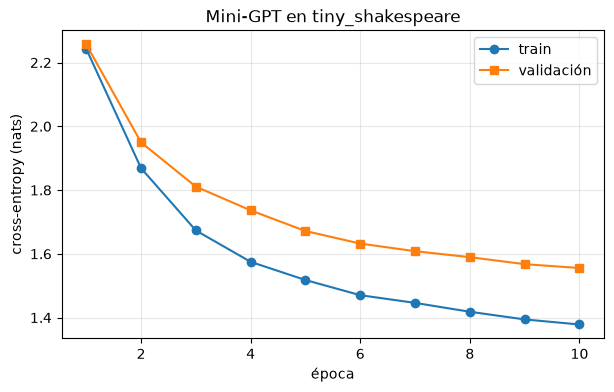

pérdida val: 1.5555 | perplejidad val: 4.737
¿dentro del rango esperado [3.5, 8.0]? True


In [7]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, epochs + 1), train_losses, marker="o", label="train")
plt.plot(range(1, epochs + 1), val_losses, marker="s", label="validación")
plt.xlabel("época")
plt.ylabel("cross-entropy (nats)")
plt.title("Mini-GPT en tiny_shakespeare")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

final_val_loss = val_losses[-1]
val_ppl = math.exp(final_val_loss)
print(f"pérdida val: {final_val_loss:.4f} | perplejidad val: {val_ppl:.3f}")
print("¿dentro del rango esperado [3.5, 8.0]?", 3.5 <= val_ppl <= 8.0)

La perplejidad se calcula como $\exp(\overline{\mathcal{L}})$. Puede interpretarse como un número efectivo de alternativas: una perplejidad cercana a 5 representa una incertidumbre equivalente a elegir uniformemente entre unas cinco continuaciones, aunque el vocabulario tenga 65 caracteres.

## Task 1.3 - Funciones de muestreo desde cero

In [8]:
def sample_greedy(logits):
    return int(torch.argmax(logits).item())


def sample_top_k(logits, k, tau):
    if tau <= 0:
        raise ValueError("tau debe ser positivo")
    if not 1 <= k <= logits.numel():
        raise ValueError("k debe estar entre 1 y el tamaño del vocabulario")

    scaled = logits / tau
    values, indices = torch.topk(scaled, k=k)
    filtered = torch.full_like(scaled, float("-inf"))
    filtered[indices] = values  # exactamente k candidatos
    probs = torch.softmax(filtered, dim=-1)
    return int(torch.multinomial(probs, num_samples=1).item())


def top_p_distribution(logits, p, tau):
    if tau <= 0:
        raise ValueError("tau debe ser positivo")
    if not 0 < p <= 1:
        raise ValueError("p debe pertenecer a (0, 1]")

    probs = torch.softmax(logits / tau, dim=-1)
    sorted_probs, sorted_indices = torch.sort(probs, descending=True)
    cumulative = torch.cumsum(sorted_probs, dim=-1)

    # Conserva el token que hace que la suma acumulada alcance o supere p.
    keep = (cumulative - sorted_probs) < p
    nucleus_probs = torch.where(keep, sorted_probs, torch.zeros_like(sorted_probs))
    nucleus_probs = nucleus_probs / nucleus_probs.sum()
    return nucleus_probs, sorted_indices, int(keep.sum().item())


def sample_top_p(logits, p, tau):
    nucleus_probs, sorted_indices, _ = top_p_distribution(logits, p, tau)
    choice = torch.multinomial(nucleus_probs, num_samples=1)
    return int(sorted_indices[choice].item())


# Pruebas mínimas de soporte y determinismo.
test_logits = torch.tensor([2.0, 1.0, 0.5, 0.1, -1.0])
assert sample_greedy(test_logits) == 0
draws_k = [sample_top_k(test_logits, k=2, tau=1.0) for _ in range(1000)]
draws_p = [sample_top_p(test_logits, p=0.5, tau=1.0) for _ in range(1000)]
print("greedy:", sample_greedy(test_logits))
print("top-k k=2:", sorted(set(draws_k)))
print("top-p p=0.5:", sorted(set(draws_p)))

greedy: 0
top-k k=2: [0, 1]
top-p p=0.5: [0]


## Task 2.1 - Generación con las cinco configuraciones

In [9]:
@torch.no_grad()
def generate(prompt, max_new_tokens, strategy, return_trace=False, **kwargs):
    model.eval()
    ids = encode(prompt)
    trace = []

    for step in range(max_new_tokens):
        context = torch.tensor([ids[-block_size:]], device=device)
        logits, _ = model(context)
        next_logits = logits[0, -1]

        if strategy == "greedy":
            next_id = sample_greedy(next_logits)
            candidate_count = 1
            tau = 1.0
        elif strategy == "top_k":
            tau = kwargs["tau"]
            next_id = sample_top_k(next_logits, kwargs["k"], tau)
            candidate_count = kwargs["k"]
        elif strategy == "top_p":
            tau = kwargs["tau"]
            probs, sorted_indices, candidate_count = top_p_distribution(
                next_logits, kwargs["p"], tau
            )
            choice = torch.multinomial(probs, num_samples=1)
            next_id = int(sorted_indices[choice].item())
        else:
            raise ValueError(f"estrategia desconocida: {strategy}")

        if return_trace:
            full_probs = torch.softmax(next_logits / tau, dim=-1)
            entropy = float(-(full_probs * torch.log(full_probs + 1e-12)).sum())
            trace.append({
                "paso": step,
                "carácter": itos[next_id],
                "candidatos": candidate_count,
                "entropía": entropy,
            })

        ids.append(next_id)

    generated = decode(ids)
    return (generated, trace) if return_trace else generated


configs = {
    "A": dict(strategy="greedy"),
    "B": dict(strategy="top_k", k=5, tau=0.7),
    "C": dict(strategy="top_k", k=50, tau=1.0),
    "D": dict(strategy="top_p", p=0.70, tau=0.7),
    "E": dict(strategy="top_p", p=0.95, tau=1.0),
}

In [10]:
torch.manual_seed(SEED)
samples = {}
sample_traces = {}

for name, config in configs.items():
    samples[name] = []
    sample_traces[name] = []
    for _ in range(5):
        generated, trace = generate(
            "ROMEO:", 200, return_trace=True, **config
        )
        samples[name].append(generated)
        sample_traces[name].append(trace)

    print("=" * 70)
    print(f"Configuración {name}: {config}")
    print("=" * 70)
    for sample_number, sample in enumerate(samples[name], 1):
        print(f"--- muestra {name}{sample_number} ---")
        print(sample)
        print()

Configuración A: {'strategy': 'greedy'}
--- muestra A1 ---
ROMEO:
The prince of the prince of the sent of the senter
That the prince of the prince of the prince of the state,
That thou shalt be so so the state of the prince,
That thou shalt be so so the state of th

--- muestra A2 ---
ROMEO:
The prince of the prince of the sent of the senter
That the prince of the prince of the prince of the state,
That thou shalt be so so the state of the prince,
That thou shalt be so so the state of th

--- muestra A3 ---
ROMEO:
The prince of the prince of the sent of the senter
That the prince of the prince of the prince of the state,
That thou shalt be so so the state of the prince,
That thou shalt be so so the state of th

--- muestra A4 ---
ROMEO:
The prince of the prince of the sent of the senter
That the prince of the prince of the prince of the state,
That thou shalt be so so the state of the prince,
That thou shalt be so so the state of th

--- muestra A5 ---
ROMEO:
The prince of the prince o

Configuración B: {'strategy': 'top_k', 'k': 5, 'tau': 0.7}
--- muestra B1 ---
ROMEO:
All the prince, and then, but which is a cure.

KING RICHARD III:
And that I will be that stard and speak a bed:
What thou hast thou do not for the bed will be and to be mine
Still that strange the p

--- muestra B2 ---
ROMEO:
Sir, and to see in thee of the fire with a children,
Who wants and the son to the some subs to thee
To the proud of his sent to murder and him,
And the crown our hands to the fire of my son:
Therefor

--- muestra B3 ---
ROMEO:
I was to him.

CORIOLANUS:
I see you to your honour,
And well have the cause of your stoops and me.

GEORY:
The sentless of his loves on the severence of me
this pardon of the prince of the sent of y

--- muestra B4 ---
ROMEO:
Why shall I have not my son, that will thou dost
A prevoked and strange worship of the sense to the brother.
And stand the beats of the side and the forth.

KING EDWARD IV:
This servant she that shal

--- muestra B5 ---
ROMEO:
And so 

Configuración C: {'strategy': 'top_k', 'k': 50, 'tau': 1.0}
--- muestra C1 ---
ROMEO:
Then, my run: I am in the sink; gentle lick of the prize
take and not weep suffer's needs? what, sir; tell it not, it so I
the high awakended call be gravel with I have a cation:
While is the fiends 

--- muestra C2 ---
ROMEO:
Six with the Lord Warwick two not my hand;
To begainst deserve your Henry famour,
That prevent of the world; but I want Maughter's life?

ROMEO:
This captin.

Provost:
'Tis queen, my first: as you no

--- muestra C3 ---
ROMEO:
Cry the post, my virtue life and we in the poorm Tyrrel
enemy to light insories: but a raw of his
heaven grief.

HERMIO:
My crack, every friends of a-father more to my enemies:
My father, she revove 

--- muestra C4 ---
ROMEO:
Blad being him know you
for thy lord. From I may will. The live sur, give all
In your prince and honour'd these have blood of young, I fly,
But you are Edward's children. The life?
Therefore two perf

--- muestra C5 ---
ROMEO:
But af

Configuración D: {'strategy': 'top_p', 'p': 0.7, 'tau': 0.7}
--- muestra D1 ---
ROMEO:
How now, that I shall be so for my state to thee,
To save the consul of the seat of my forth
That shall be man of your stranger to him,
And be my son with the triumph of your honour shall
And the bea

--- muestra D2 ---
ROMEO:
That thou hast do the tribune of the city
That was the way of my time of the fire such and the death,
I must be confess to the battle of a prince and false.

GLOUCESTER:
So many life and for the son 

--- muestra D3 ---
ROMEO:
The duke of what shall be come of him him.

PERDITA:
What is thou hast not not so much desperate,
The prince that break with some hands to the seat
To prove a father death him some hath offenced the 

--- muestra D4 ---
ROMEO:
Here the grace of my prince, and the people to the house,
To be so this burther of his honour's bear and my father's
for stands should see the beggar of and all the true
That I do not stay a too this

--- muestra D5 ---
ROMEO:
Then 

Configuración E: {'strategy': 'top_p', 'p': 0.95, 'tau': 1.0}
--- muestra E1 ---
ROMEO:
Are thy heart! Farewell, my lord of itself
As wear some are not, in their mortal redemn'd.
Would day the pity tide your matter?

MENENIUS:
Give be him, for you forth with the abroad,
And proud but to

--- muestra E2 ---
ROMEO:
Tell this day, sir, afford!

LEONTES:
Never not spite daughter on think?

ESCALUS:
I had way, by matter him free to the poor off,
To pounding it enough for our pains prepart on you,
and not the point

--- muestra E3 ---
ROMEO:
Came a paulting, worthy galled of the brother's majesty:
Well, whom you were have done have to myself,
That my soul, but little gloving you, and my born,
But right whose chasity should never in me
a 

--- muestra E4 ---
ROMEO:
If you do be you supply, the wall.

AUTOLYCUS:
A fair take, not fall the forbeast
That I cried to for thee in vise: what your beat and doubly
Even sentence.

Nurse:
I was another upon his foot? Your 

--- muestra E5 ---
ROMEO:
That

## Task 2.2 - Análisis de las muestras

In [11]:
def distinct_ngrams(text, n):
    ngrams = [text[i : i + n] for i in range(len(text) - n + 1)]
    return len(set(ngrams)) / max(1, len(ngrams))


diversity_rows = []
for name, group in samples.items():
    suffixes = [sample[len("ROMEO:") :] for sample in group]
    diversity_rows.append({
        "configuración": name,
        "muestras únicas": len(set(suffixes)),
        "distinct-3": np.mean([distinct_ngrams(sample, 3) for sample in suffixes]),
    })

diversity_df = pd.DataFrame(diversity_rows)
display(diversity_df.style.hide(axis="index").format({"distinct-3": "{:.3f}"}))

configuración,muestras únicas,distinct-3
A,1,0.278
B,5,0.716
C,5,0.883
D,5,0.741
E,5,0.880


### a. Por qué greedy repite o entra en ciclos

Greedy usa $x_{t+1}=\arg\max_i z_i$. Como softmax es monótono, esto equivale a escoger siempre el carácter de mayor probabilidad. No existe aleatoriedad: dado el mismo contexto, se obtiene la misma continuación. Por eso A1-A5 son idénticas. En las cinco aparece la secuencia “The prince of the prince”, seguida por más repeticiones de “the prince” y “the state”. El valor distinct-3 de A es 0.278, frente a valores entre 0.716 y 0.883 en las configuraciones estocásticas.

### b. Comparación entre B y C

La temperatura modifica las razones de probabilidad según

$$\frac{P_i}{P_j}=\exp\left(\frac{z_i-z_j}{\tau}\right).$$

En B, $\tau=0.7$ amplifica las diferencias entre logits y $k=5$ restringe el soporte a cinco caracteres. Esto concentra la distribución y produce palabras más estables. En C, $\tau=1.0$ conserva la distribución aprendida y $k=50$ permite casi todo el vocabulario. distinct-3 aumenta de 0.716 en B a 0.883 en C. B1 conserva fragmentos reconocibles como “All the prince” y una estructura clara de diálogo; C2 introduce formas como “begainst”, “famour” y “Maughter's”. Según estas muestras, B resulta más coherente y C más creativo. Como $k$ y $\tau$ cambian simultáneamente, este experimento no permite aislar por completo el efecto individual de cada parámetro.

Muestra E1:
ROMEO:
Are thy heart! Farewell, my lord of itself
As wear some are not, in their mortal redemn'd.
Would day the pity tide your matter?

MENENIUS:
Give be him, for you forth with the abroad,
And proud but to

Momentos de mayor seguridad:


paso,contexto,carácter,candidatos,entropía
139,? [salto] [salto] MENENIUS:,,1,0.002820
137,er? [salto] [salto] MENENIU,S,1,0.003057
138,r? [salto] [salto] MENENIUS,:,1,0.003065
136,ter? [salto] [salto] MENENI,U,1,0.003289


Momentos de mayor incertidumbre:


paso,contexto,carácter,candidatos,entropía
16,thy heart!,F,32,3.292192
37,my lord of,i,32,3.068105
44,d of itself [salto],A,30,2.926484
34,"ll, my lord",o,27,3.169611


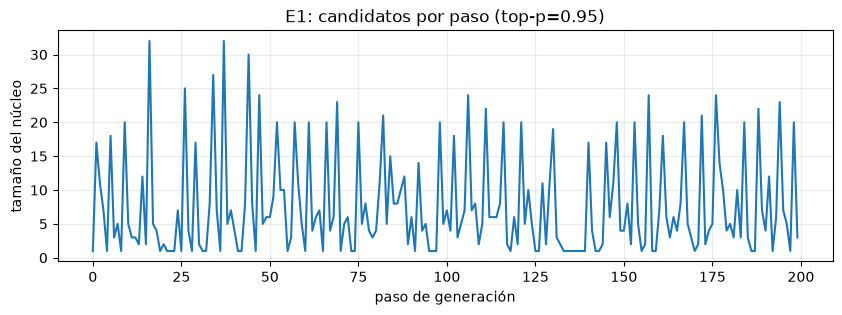

In [12]:
# Se analiza E1, una de las cinco muestras requeridas, no una corrida adicional.
e1_text = samples["E"][0]
e1_generated = e1_text[len("ROMEO:") :]
e1_trace = pd.DataFrame(sample_traces["E"][0])
e1_trace["contexto"] = [
    e1_generated[max(0, i - 12) : i].replace("\n", " [salto] ")
    for i in range(len(e1_trace))
]

secure_examples = e1_trace.nsmallest(4, ["candidatos", "entropía"])
uncertain_examples = e1_trace.nlargest(4, ["candidatos", "entropía"])

print("Muestra E1:")
print(e1_text)
print("\nMomentos de mayor seguridad:")
display(secure_examples[["paso", "contexto", "carácter", "candidatos", "entropía"]].style.hide(axis="index"))
print("Momentos de mayor incertidumbre:")
display(uncertain_examples[["paso", "contexto", "carácter", "candidatos", "entropía"]].style.hide(axis="index"))

plt.figure(figsize=(10, 3))
plt.plot(e1_trace["paso"], e1_trace["candidatos"])
plt.xlabel("paso de generación")
plt.ylabel("tamaño del núcleo")
plt.title("E1: candidatos por paso (top-p=0.95)")
plt.grid(alpha=0.25)
plt.show()

### c. Adaptación de top-p en E1

Los momentos seguros de E1 corresponden principalmente a letras dentro de palabras ya iniciadas o a signos con una continuación ortográfica muy restringida. Por ejemplo, completar MENENIU con S, agregar : después de MENENIUS y producir el salto de línea posterior requieren un solo candidato. En cambio, después de thy heart!  el carácter elegido fue F entre 32 candidatos, y después de my lord of  se eligió i también entre 32. Estos son inicios de palabra donde muchas continuaciones son posibles. E1 muestra así la diferencia entre decisiones ortográficas locales y decisiones de contenido: top-p adapta el número de candidatos en cada posición, mientras top-k lo mantiene fijo.

## Task 3.1 - Embeddings contextuales de BERT

Se usa bert-base-multilingual-cased. Para cada oración se localiza la palabra objetivo mediante sus offsets y se extrae el vector de la última capa en esa posición. Las siete palabras se tokenizan como un solo token, por lo que no es necesario promediar subpalabras.

In [13]:
from transformers import AutoModel, AutoTokenizer, logging as hf_logging

hf_logging.set_verbosity_error()
hf_logging.disable_progress_bar()

bert_items = [
    {"palabra": "banco", "sentido": "finanzas", "oración": "El banco central anunció una subida de tasas de interés."},
    {"palabra": "banco", "sentido": "asiento", "oración": "Me senté en el banco del parque a leer el periódico."},
    {"palabra": "banco", "sentido": "peces", "oración": "El banco de peces se movió velozmente ante el tiburón."},
    {"palabra": "copa", "sentido": "trofeo", "oración": "El equipo levantó la copa del torneo ante miles de aficionados."},
    {"palabra": "copa", "sentido": "bebida", "oración": "Sirvió una copa de vino tinto para acompañar la cena."},
    {"palabra": "vela", "sentido": "navegación", "oración": "El velero desplegó su vela para aprovechar el viento."},
    {"palabra": "vela", "sentido": "cera", "oración": "Encendió una vela para iluminar el cuarto durante el apagón."},
]

bert_name = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(bert_name)
bert_model = AutoModel.from_pretrained(bert_name).to(device)
bert_model.eval()

@torch.no_grad()
def extract_target_embedding(sentence, target):
    start = sentence.lower().index(target.lower())
    end = start + len(target)
    encoded = tokenizer(
        sentence,
        return_offsets_mapping=True,
        return_tensors="pt",
    )
    offsets = encoded.pop("offset_mapping")[0].tolist()
    positions = [
        i for i, (left, right) in enumerate(offsets)
        if left < end and right > start
    ]
    if not positions:
        raise ValueError(f"No se encontró el token de {target!r}")

    tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"][0, positions])
    encoded = {name: tensor.to(device) for name, tensor in encoded.items()}
    hidden = bert_model(**encoded).last_hidden_state[0, positions]
    # Si hubiera varias subpalabras, se promedian sus representaciones.
    vector = hidden.mean(dim=0).cpu().numpy()
    return vector, tokens


bert_vectors = []
token_rows = []
for item in bert_items:
    vector, tokens = extract_target_embedding(item["oración"], item["palabra"])
    assert vector.shape == (768,)
    bert_vectors.append(vector)
    token_rows.append({
        "palabra": item["palabra"],
        "sentido": item["sentido"],
        "tokens usados": tokens,
        "dimensión": vector.shape[0],
    })

bert_vectors = np.stack(bert_vectors)
display(pd.DataFrame(token_rows).style.hide(axis="index"))

palabra,sentido,tokens usados,dimensión
banco,finanzas,['banco'],768
banco,asiento,['banco'],768
banco,peces,['banco'],768
copa,trofeo,['copa'],768
copa,bebida,['copa'],768
vela,navegación,['vela'],768
vela,cera,['vela'],768


## Task 3.2 - Similitud coseno, Word2Vec y PCA

In [14]:
def cosine(u, v):
    return float(np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v)))


pair_rows = []
for word in ("banco", "copa", "vela"):
    indices = [i for i, item in enumerate(bert_items) if item["palabra"] == word]
    for left, right in combinations(indices, 2):
        pair_rows.append({
            "palabra": word,
            "contexto 1": bert_items[left]["sentido"],
            "contexto 2": bert_items[right]["sentido"],
            "similitud BERT": cosine(bert_vectors[left], bert_vectors[right]),
        })

bert_similarity_df = pd.DataFrame(pair_rows)
display(bert_similarity_df.style.hide(axis="index").format({"similitud BERT": "{:.4f}"}))

palabra,contexto 1,contexto 2,similitud BERT
banco,finanzas,asiento,0.5753
banco,finanzas,peces,0.6603
banco,asiento,peces,0.6496
copa,trofeo,bebida,0.5667
vela,navegación,cera,0.7999


In [15]:
import gzip
import requests
from gensim.models import KeyedVectors

word2vec_path = Path("sbw_cbow_targets.npz")
word2vec_url = "https://cs.famaf.unc.edu.ar/~ccardellino/SBWCE/SBW-vectors-300-min5-cbow.bin.gz"
target_words = {"banco", "copa", "vela"}

def download_selected_word2vec_vectors(path):
    # Extrae solo los tres vectores requeridos del modelo Word2Vec español.
    found = {}
    with requests.get(word2vec_url, stream=True, timeout=(30, 120)) as response:
        response.raise_for_status()
        response.raw.decode_content = False
        with gzip.GzipFile(fileobj=response.raw) as stream:
            vocab_size, vector_size = map(int, stream.readline().split())
            for _ in range(vocab_size):
                word_bytes = bytearray()
                while True:
                    byte = stream.read(1)
                    if byte == b" ":
                        break
                    if byte and byte != b"\n":
                        word_bytes.extend(byte)
                word = word_bytes.decode("utf-8", errors="replace")
                raw_vector = stream.read(4 * vector_size)
                if word in target_words:
                    found[word] = np.frombuffer(raw_vector, dtype=np.float32).copy()
                    if found.keys() >= target_words:
                        break
    if found.keys() != target_words:
        raise RuntimeError(f"Faltan vectores: {target_words - found.keys()}")
    np.savez(path, **found)


if not word2vec_path.exists():
    download_selected_word2vec_vectors(word2vec_path)

saved_vectors = np.load(word2vec_path)
static_model = KeyedVectors(vector_size=300)
static_model.add_vectors(
    sorted(target_words),
    np.stack([saved_vectors[word] for word in sorted(target_words)]),
)

print("modelo estático: Spanish Billion Word Corpus Word2Vec CBOW")
print("dimensión:", static_model.vector_size)
print("palabras cargadas:", sorted(static_model.key_to_index))

modelo estático: Spanish Billion Word Corpus Word2Vec CBOW
dimensión: 300
palabras cargadas: ['banco', 'copa', 'vela']


In [16]:
# Word2Vec asigna un único vector a cada palabra, sin importar la oración.
comparison_df = bert_similarity_df.copy()
comparison_df["similitud Word2Vec"] = [
    cosine(static_model[row["palabra"]], static_model[row["palabra"]])
    for _, row in comparison_df.iterrows()
]
display(comparison_df.style.hide(axis="index").format({
    "similitud BERT": "{:.4f}",
    "similitud Word2Vec": "{:.4f}",
}))

palabra,contexto 1,contexto 2,similitud BERT,similitud Word2Vec
banco,finanzas,asiento,0.5753,1.0000
banco,finanzas,peces,0.6603,1.0000
banco,asiento,peces,0.6496,1.0000
copa,trofeo,bebida,0.5667,1.0000
vela,navegación,cera,0.7999,1.0000


Word2Vec devuelve similitud 1 para cada par porque las dos apariciones de una palabra consultan exactamente el mismo vector estático. En BERT todas las similitudes son menores que 1: el vector cambia con la oración. *Copa* presenta una similitud de 0.5667 entre trofeo y bebida, mientras *vela* alcanza 0.7999 entre navegación y cera. Para *banco*, las tres comparaciones quedan entre 0.5753 y 0.6603. BERT distingue los contextos, aunque el grado de separación no coincide necesariamente con una taxonomía lingüística perfecta.

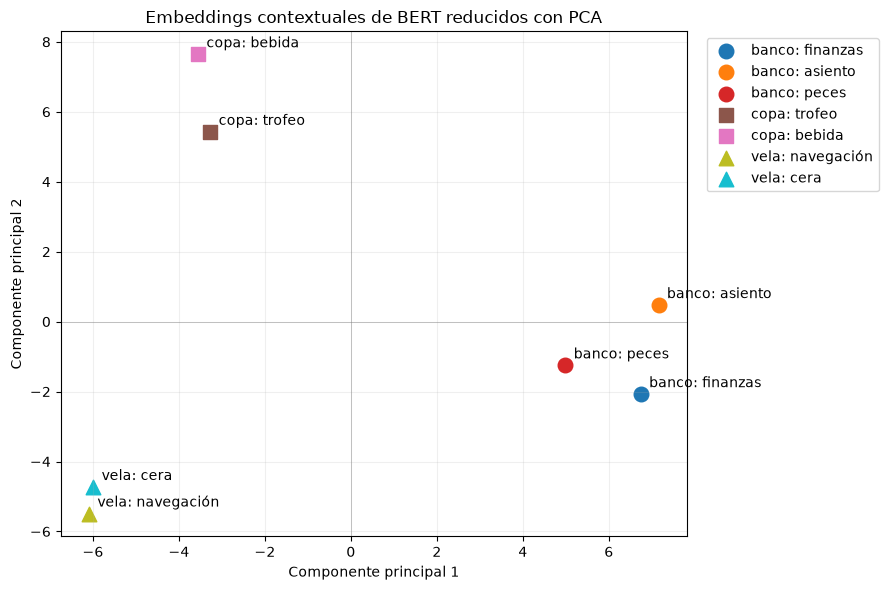

varianza explicada por PC1 y PC2: [0.3502123  0.23540515]
varianza explicada total: 0.5856174


In [17]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
bert_2d = pca.fit_transform(bert_vectors)

plot_df = pd.DataFrame({
    "x": bert_2d[:, 0],
    "y": bert_2d[:, 1],
    "palabra": [item["palabra"] for item in bert_items],
    "sentido": [item["sentido"] for item in bert_items],
})

colors = plt.cm.tab10(np.linspace(0, 1, len(plot_df)))
markers = {"banco": "o", "copa": "s", "vela": "^"}

plt.figure(figsize=(9, 6))
for i, row in plot_df.iterrows():
    label = f'{row["palabra"]}: {row["sentido"]}'
    plt.scatter(
        row["x"], row["y"],
        color=colors[i], marker=markers[row["palabra"]],
        s=110, label=label,
    )
    plt.annotate(label, (row["x"], row["y"]), xytext=(6, 5), textcoords="offset points")

plt.axhline(0, color="gray", linewidth=0.6, alpha=0.5)
plt.axvline(0, color="gray", linewidth=0.6, alpha=0.5)
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title("Embeddings contextuales de BERT reducidos con PCA")
plt.grid(alpha=0.2)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("varianza explicada por PC1 y PC2:", pca.explained_variance_ratio_)
print("varianza explicada total:", pca.explained_variance_ratio_.sum())

En la proyección, la identidad de la palabra explica una parte importante de la variación: las instancias de *banco*, *copa* y *vela* forman regiones distintas. Dentro de cada palabra, los significados ocupan puntos diferentes, pero no siempre quedan muy alejados en dos dimensiones. PC1 y PC2 conservan en conjunto 58.56% de la varianza, por lo que la tabla de similitudes es la evidencia cuantitativa principal y la gráfica funciona como resumen visual.

## Task 4.1 - GPT, BERT y preentrenamiento

### a. Necesidad de la máscara causal

En language modeling autoregresivo se factoriza la probabilidad de una secuencia como

$$P(x_1,\ldots,x_T)=\prod_{t=1}^{T}P(x_t\mid x_{<t}).$$

La máscara causal hace que la representación usada para predecir $x_{t+1}$ dependa únicamente de $x_{\leq t}$. Si GPT utilizara atención bidireccional durante este entrenamiento, la posición $t$ podría consultar la posición $t+1$, que contiene el token que debe predecir. La pérdida bajaría mediante fuga de información y dejaría de medir la capacidad de anticipar el siguiente token. En generación esa información futura no existe, de modo que habría una discrepancia entre entrenamiento e inferencia y el objetivo dejaría de ser válido.

### b. Elección entre GPT y BERT

BERT usa contexto izquierdo y derecho durante el preentrenamiento enmascarado. Esa atención bidireccional es adecuada para construir representaciones de una oración completa, pero no define directamente una distribución autoregresiva del siguiente token. Los resultados del Task 3 muestran la ventaja contextual: Word2Vec produce similitud 1 para dos apariciones de la misma palabra, mientras BERT produce valores menores que 1 y distingue sus usos. *Copa* presenta la separación más marcada; *vela* conserva mayor similitud, pero aun así cambia con el contexto.

GPT también genera representaciones contextuales, pero al producir texto solo puede usar el prefijo disponible. Su arquitectura y objetivo causal están alineados con generación. El paradigma de preentrenar y adaptar permite escoger el modelo según la tarea: GPT para continuación y generación; BERT para clasificación, extracción o comparación semántica con contexto bidireccional. En ambos casos se parte de conocimiento lingüístico aprendido en grandes corpus y solo se adapta o utiliza el modelo preentrenado, sin entrenarlo desde cero.

## Fuentes y herramientas

- Dataset: [tiny_shakespeare](https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt).
- Modelo contextual: [bert-base-multilingual-cased](https://huggingface.co/bert-base-multilingual-cased).
- Vectores estáticos: [Spanish Billion Word Corpus and Embeddings](https://crscardellino.github.io/SBWCE/), modelo Word2Vec CBOW de 300 dimensiones entrenado con gensim.

Se utilizó asistencia automatizada para contrastar el notebook con la consigna y localizar errores técnicos. Resumen del prompt utilizado: “Analiza el laboratorio y el trabajo existente, y dime si hay algun error grave para corregir”. Fue útil porque fijó el alcance de la revisión y exigió comprobar cada resultado mediante la ejecución del código.